In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from scipy.interpolate import interp1d
from scipy.special import gamma

In [2]:
H = 300
h = 1e-8
ecf = 0.1
efc = 3
ecc = 3
a = 0.5
b = 1
lam = 4
alpha = 2
delta = 1e-6
kappa = 0.03
#Tmax = 36e4+1
#arrays = {}
T = 1


q = 1.5
c = np.power((np.sqrt(np.pi)*gamma((3-q)/(2*(q-1))))/(np.sqrt(q-1)*gamma(1/(q-1))),2)
coef_a = np.sqrt(np.pi*(lam-1))*gamma((lam-1)/2)/gamma(lam/2)
coef_b = (lam-2)*T/lam
sigma_q = np.power(coef_a,1/(lam-1))*np.power(coef_b,lam/(2*(lam-1)))
beta = 1/(3-q)

In [3]:
def LogPrice (xi, ei):
    return ((1-xi)*ei)/xi

def UsTau (xi, ei):
    coef = a*np.abs(LogPrice(xi,ei))
    return np.power(1+coef,alpha)

def Delta_t (xi, ei):
    num = kappa*kappa
    den = h*UsTau(xi,ei)*(1+efc+ecf+H*(1+2*ecc))
    return num/den

def AvanceXi (xi,ei):
    temp = h*Delta_t(xi,ei)*(((1-xi)*ecf*UsTau(xi,ei))-(xi*efc))
    ale = np.sqrt((1-xi)*2*h*xi*Delta_t(xi,ei)*UsTau(xi,ei))*np.random.normal(0, 1)
    return xi+temp+ale

def AvanceEi (xi,ei):
    temp = 2*H*h*ecc*ei*Delta_t(xi,ei)*UsTau(xi,ei)
    ale = np.sqrt((1-ei*ei)*2*h*H*Delta_t(xi,ei)*UsTau(xi,ei))*np.random.normal(0, 1)
    return ei-temp+ale

def inter(t1, x1, t2, x2, t):
    """Interpola x en el tiempo t entre los puntos (t1, x1) y (t2, x2)."""
    return x1 + (x2 - x1) * (t - t1) / (t2 - t1)

# PDF
def q_gaussian(x, q, beta):
    z = 1 - (1 - q) * beta * x**2
    zeta = np.sqrt(c/beta)
    return np.where(z > 0, (z**(1 / (1 - q)))/zeta, 0)


def generate_q_gaussian_samples(q, beta, size, x_range=1000, resolution=1000000):
    """
    Genera muestras de una q-gaussiana usando la transformación inversa numérica.
    """
    if q >= 3:
        raise ValueError("Este método requiere q < 3 para que la PDF sea integrable.")

    # Dominio x
    x_vals = np.linspace(-x_range, x_range, resolution)
    pdf_vals = q_gaussian(x_vals, q, beta)

    # CDF por integración numérica (hasta constante)
    cdf_vals = cumtrapz(pdf_vals, x_vals, initial=0)
    #cdf_vals /= cdf_vals[-1]  # Normalizamos

    # Inversa de la CDF
    inv_cdf = interp1d(cdf_vals, x_vals, bounds_error=False, fill_value=(x_vals[0], x_vals[-1]))

    # Muestras
    u = np.random.uniform(0, 1, size)
    samples = inv_cdf(u)
    return samples, x_vals, pdf_vals, cdf_vals

In [4]:
# Definimos los parámetros base
Tmax_values = {
    "t1": int(36e6 + 1),  
    "t2": int(42e6 + 1),  
    "t3": int(48e6 + 1),  
    "t4": int(54e5 + 1),
    "t5": int(60e6 + 1),  
    "t6": int(66e6 + 1),  
    "t7": int(72e6 + 1),  
    "t8": int(78e6 + 1), 
}
# Diccionarios para almacenar resultados
results = {}
histograms = {}

for name, Tmax in Tmax_values.items():
    np.random.seed(25)  # Puedes usar cualquier número entero

    # Inicialización de arrays
    size_min = int(Tmax/60) + 1
    r_i = np.zeros(size_min)
    
    # Variables de simulación
    Xiprev, Eiprev, tprev = 0.6, 0.0, 0.0
    t_target = np.arange(0, Tmax, 60)
    t, i = 0.0, 1
    
    # Simulación
    while t < Tmax:
        AvXi = min(max(AvanceXi(Xiprev, Eiprev), delta), 1-delta)
        AvEi = min(max(AvanceEi(Xiprev, Eiprev), -1 + delta), 1-delta)
        t += Delta_t(Xiprev, Eiprev)
        
        if i>=size_min:
            break

        if t_target[i] > tprev and t_target[i] < t:
            x_i_temp = inter(tprev, Xiprev, t, AvXi, t_target[i])
            e_i_temp = inter(tprev, Eiprev, t, AvEi, t_target[i])
            r_i[i] = b * (1 + a * np.abs(LogPrice(x_i_temp, e_i_temp))) * np.sqrt(T)
            i += 1
            
        tprev, Xiprev, Eiprev = t, AvXi, AvEi
    
    # Resultados de la simulación
    samples, x_vals, pdf_vals, cdf_vals = generate_q_gaussian_samples(q, beta, size_min)
    r_target = r_i*samples*sigma_q
    data_abs = np.abs(r_target)
    data_abs /= np.std(data_abs)
    
    # Almacenamos resultados
    results[name] = data_abs

C:\Users\samue\AppData\Local\Temp\ipykernel_38332\268706878.py:46: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_vals = cumtrapz(pdf_vals, x_vals, initial=0)


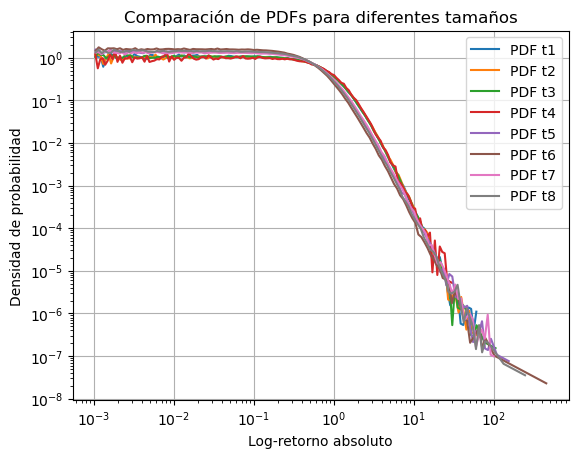

In [5]:
# Procesamiento de histogramas
#plt.figure(figsize=(10, 6))
for name, data in results.items():
    data_abs = data
    num_bins = np.logspace(np.log10(1e-3), np.log10(max(data_abs)), 150)
    hist, bin_edges = np.histogram(data_abs, bins=num_bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    
    nonzero_mask = hist > 0
    hist = hist[nonzero_mask]
    bin_centers = bin_centers[nonzero_mask]
    
    histograms[name] = {
        'hist': hist,
        'bin_centers': bin_centers
    }
    
    # Graficamos
    plt.loglog(bin_centers, hist, label=f'PDF {name}')

# Configuración final del gráfico
plt.xlabel('Log-retorno absoluto')
plt.ylabel('Densidad de probabilidad')
plt.title('Comparación de PDFs para diferentes tamaños')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
np.savetxt('q-Noise.txt', results["t8"], fmt='%.20f')  # 3 decimales

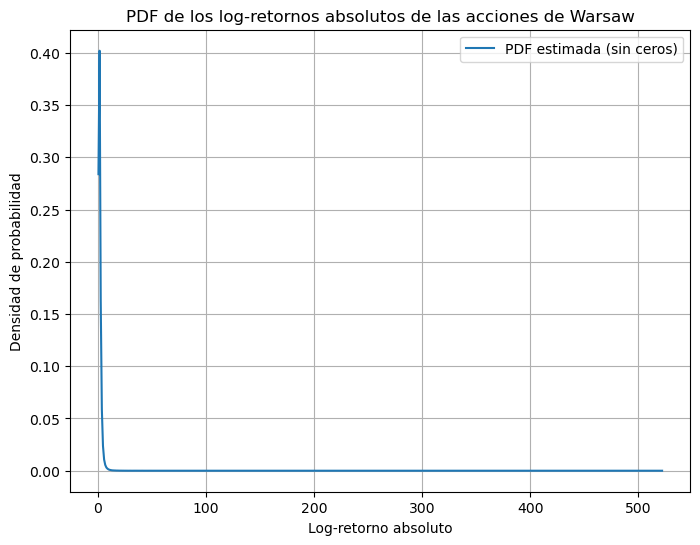

In [10]:
data_abs = Diario


# Calcular histograma normalizado (PDF)
hist, bin_edges = np.histogram(data_abs, bins=500, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# **Eliminar valores cero de la PDF y sus correspondientes bins**
nonzero_mask = hist > 0  # Máscara para valores distintos de cero
hist = hist[nonzero_mask]
bin_centers = bin_centers[nonzero_mask]

# Graficar la PDF sin ceros
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, hist, label='PDF estimada (sin ceros)')
plt.xlabel('Log-retorno absoluto')
plt.ylabel('Densidad de probabilidad')
plt.title('PDF de los log-retornos absolutos de las acciones de Warsaw')
plt.legend()
plt.grid(True)
# Mostrar gráfica
plt.show()